In [ ]:
# Shor's algorithm, m = 35, a = 2

In [23]:
# import libraries

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from math import gcd
from fractions import Fraction

import qiskit
from qiskit import QuantumCircuit, transpile

from qiskit.circuit.library import QFTGate, UnitaryGate
from qiskit_aer import AerSimulator, StatevectorSimulator
from qiskit_aer.primitives import Sampler as AerSampler
from qiskit.visualization import plot_histogram

In [24]:
# N = 35
# controlled-U block

def c_amod35(a, power):
    """Controlled multiplication by a^power mod 35"""
    
    if gcd(a, 35) != 1:
        raise ValueError("'a' must be coprime to 35")
    
    n_work = 6
    dim = 2**n_work
    
    # the permutation matrix for:
    # |y> -> |a^power * y mod 35>   for y < 35
    # |y> -> |y>                    for y >= 35
    
    U = np.zeros((dim, dim), dtype=complex)
    a_power = pow(a, power, 35)
    
    for y in range(dim):
        if y < 35:
            target = (a_power * y) % 35
        else:
            target = y
        U[target, y] = 1.0
    
    U_gate = UnitaryGate(U)
    U_gate.name = f"{a}^{power} mod 35"
    
    c_U = U_gate.control()
    return c_U

In [25]:
# 8 counting qubits
# select "a"

N_COUNT = 8
a = 2

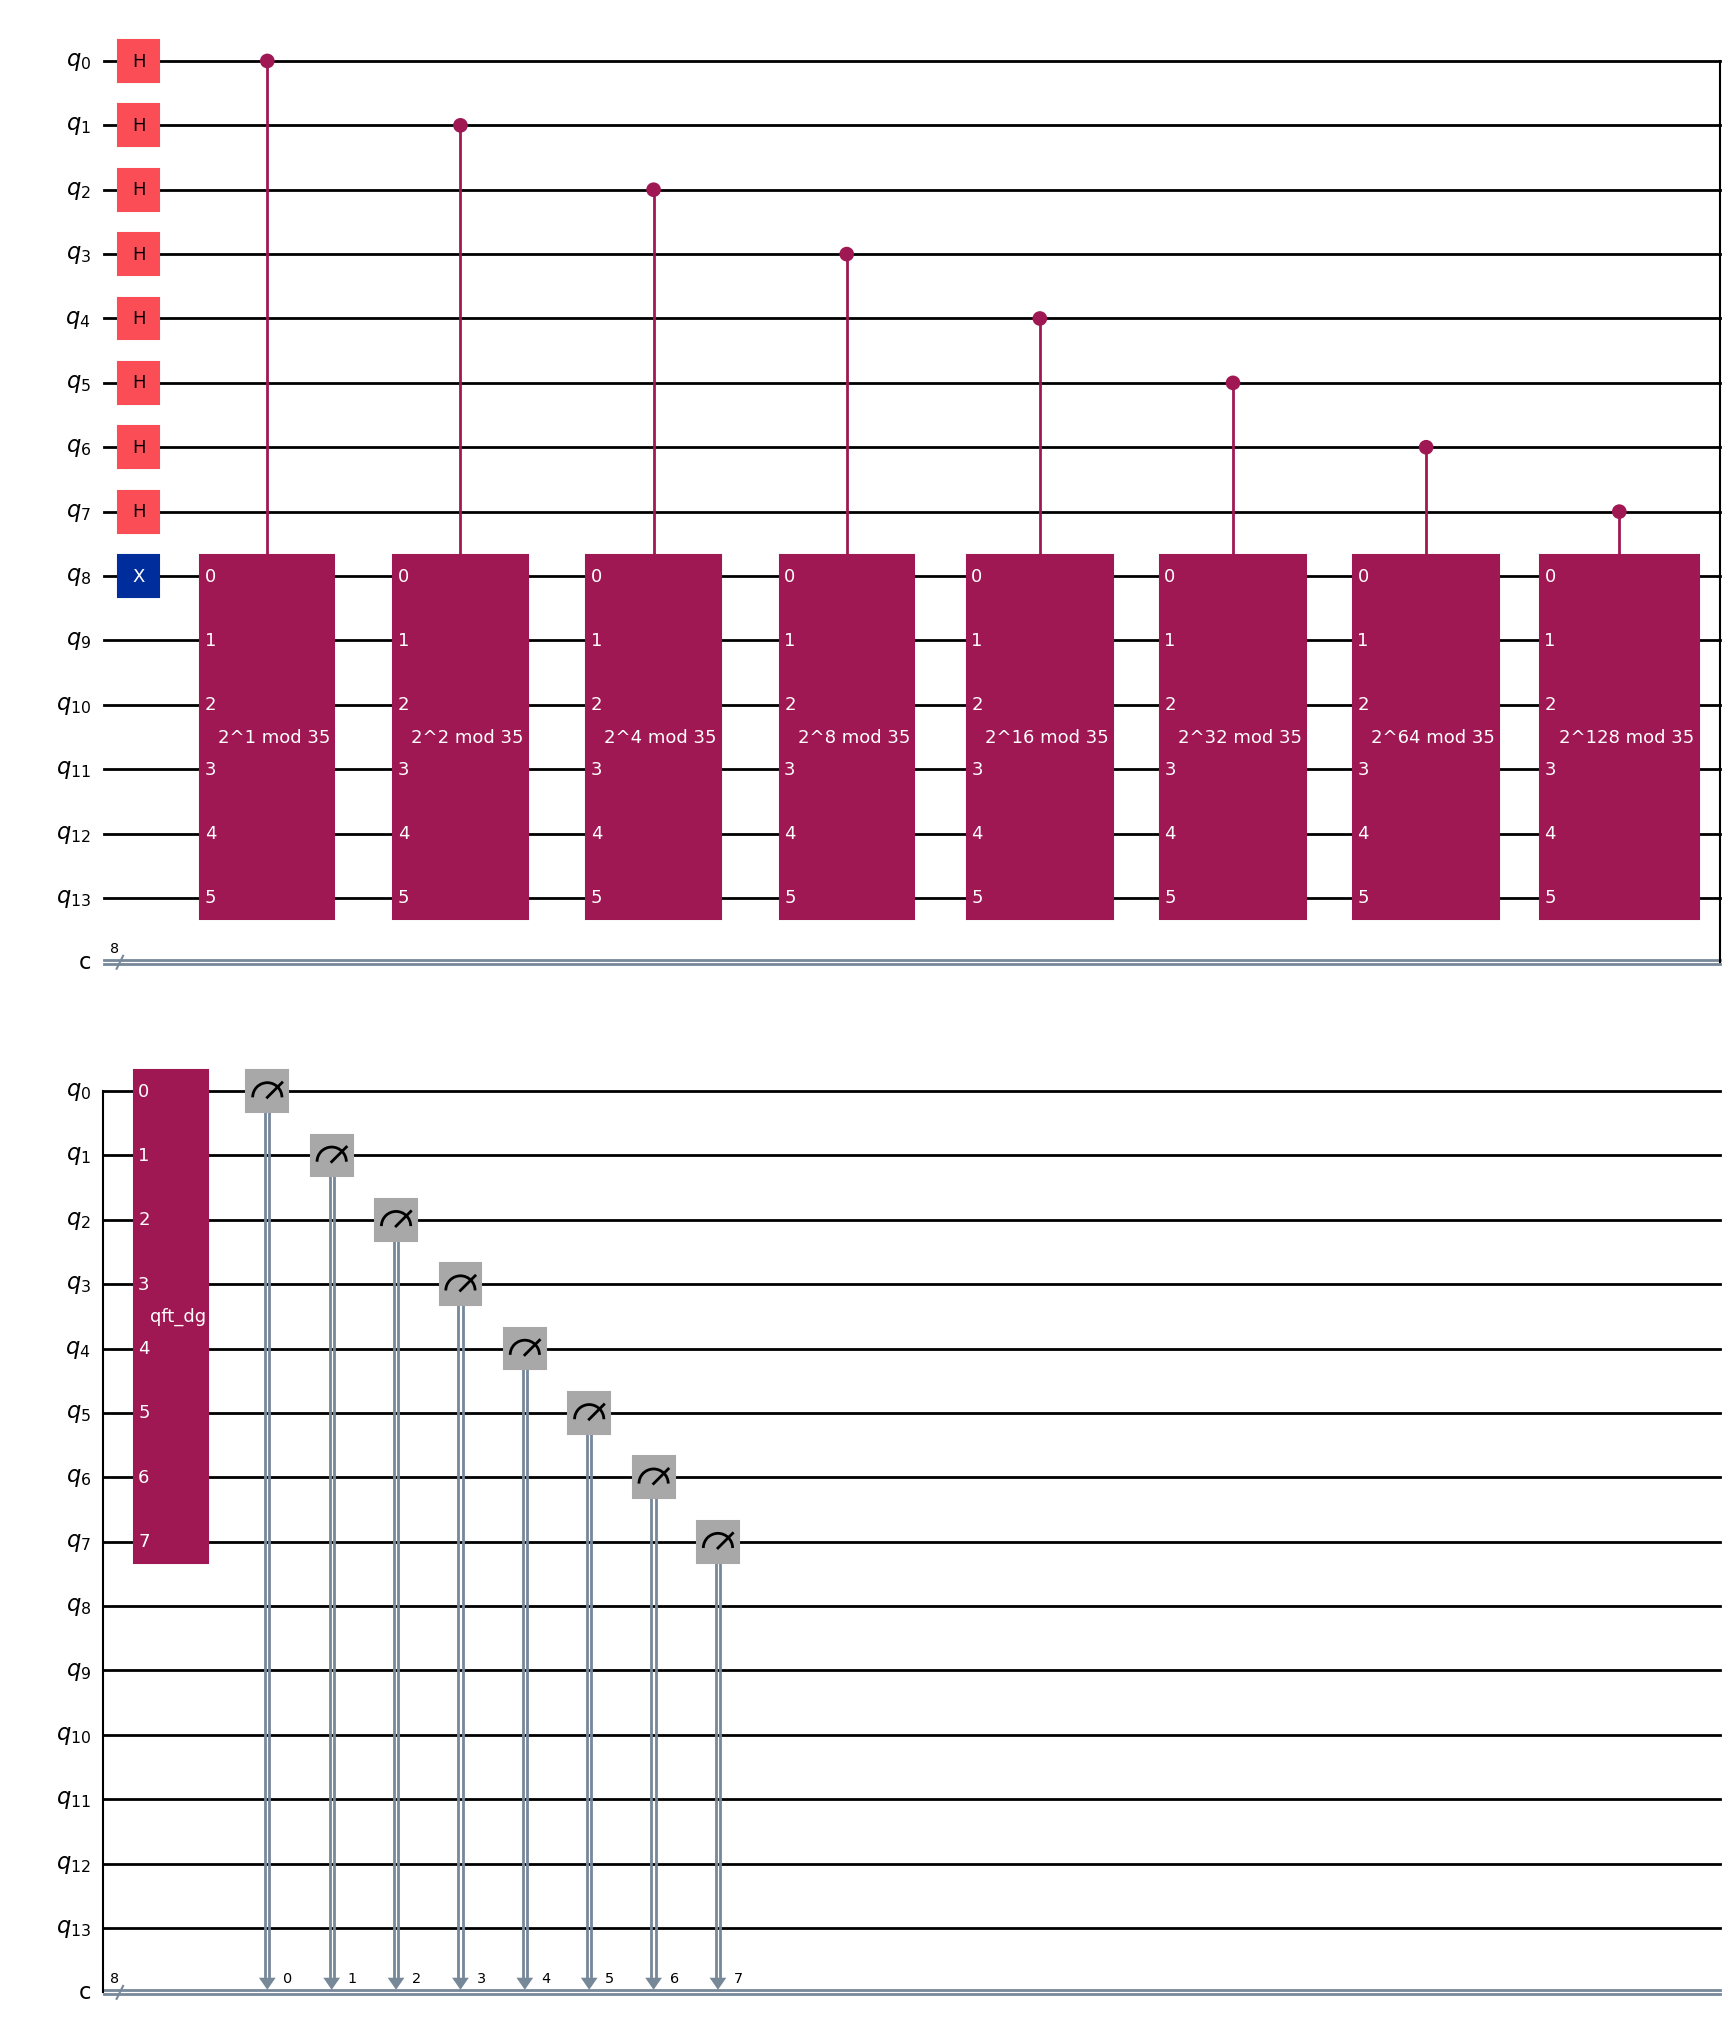

In [26]:
# Create QuantumCircuit with N_COUNT counting qubits
# plus 6 qubits for U to act on

### YOUR CODE HERE
qc = QuantumCircuit(N_COUNT + 6, N_COUNT)

# Initialize counting qubits
# in state |+>

### YOUR CODE HERE
for q in range(N_COUNT):
    qc.h(q)

# And auxiliary register in state |1>

### YOUR CODE HERE
qc.x(N_COUNT)   # this is the least-significant qubit of the work register

# Do controlled-U operations

for q in range(N_COUNT):
    qc.append(c_amod35(a, 2**q), [q] + [i + N_COUNT for i in range(6)])

# Do inverse-QFT

### YOUR CODE HERE
qc.append(QFTGate(N_COUNT).inverse(), range(N_COUNT))

# Measure and draw the circuit

### YOUR CODE HERE
qc.measure(range(N_COUNT), range(N_COUNT))
qc.draw('mpl')

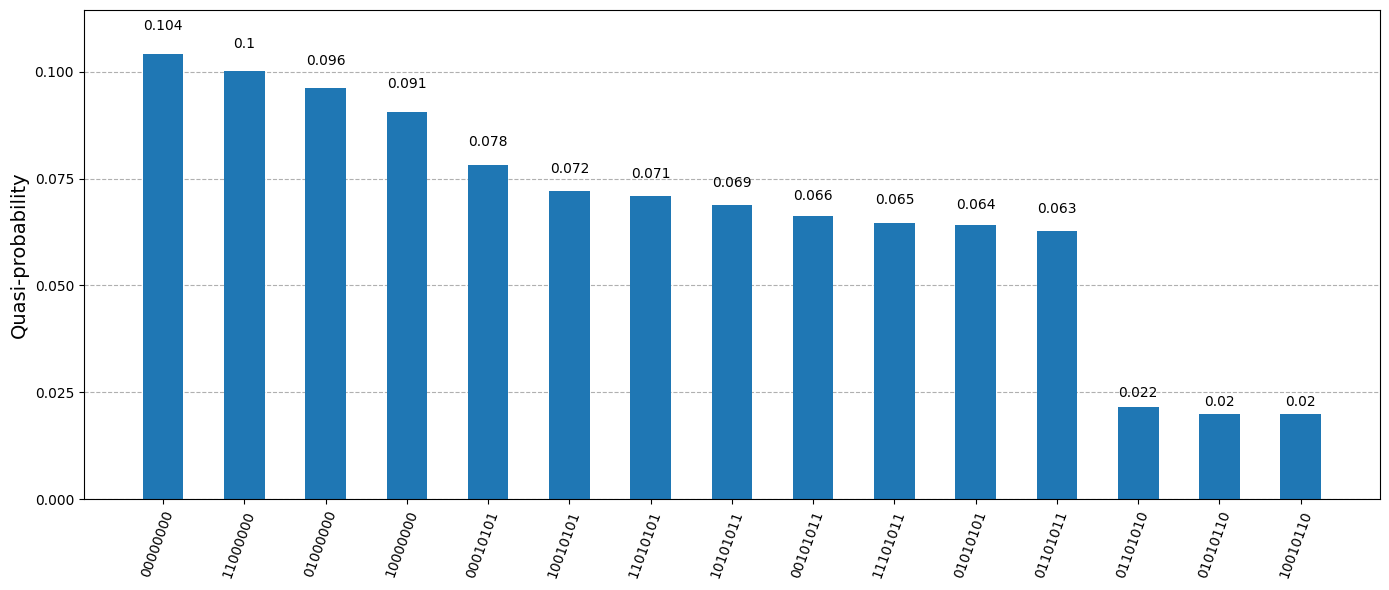

In [32]:
# Execute simulations

### YOUR CODE HERE

sampler = AerSampler()
job_sim = sampler.run(qc, shots=4096)

quasi_dists = job_sim.result().quasi_dists[0].binary_probabilities()

# Keep only the most significant outcomes
plot_histogram(
    quasi_dists,
    number_to_keep=15,
    sort='value_desc',
    figsize=(14,6),
    bar_labels=True
)

In [28]:
# Interpret results

### YOUR CODE HERE

# Sort results from most probable to least probable
sorted_results = sorted(quasi_dists.items(), key=lambda x: x[1], reverse=True)

# Show the most likely outcomes
top_results = sorted_results[:15]
top_results

[('11000000', 0.089111328125),
 ('01000000', 0.08642578125),
 ('10000000', 0.08544921875),
 ('00000000', 0.081298828125),
 ('00101011', 0.062744140625),
 ('01010101', 0.060791015625),
 ('10101011', 0.05859375),
 ('00010101', 0.058349609375),
 ('10010101', 0.05615234375),
 ('11101011', 0.0546875),
 ('01101011', 0.054443359375),
 ('11010101', 0.053466796875),
 ('11101010', 0.015625),
 ('10101010', 0.015625),
 ('01101010', 0.014892578125)]

In [29]:
# Convert bit strings to decimal values

### YOUR CODE HERE
int_keys = [k for k, v in top_results]
int_keys_decimal = [int(k, 2) for k in int_keys]

int_keys_decimal

[192, 64, 128, 0, 43, 85, 171, 21, 149, 235, 107, 213, 234, 170, 106]

In [31]:
# Discussion:
#
# For N = 35 and a = 2, the true order is
#   r = 12
# because
#   2^12 = 4096 ≡ 1 (mod 35).
#
# Therefore, phase estimation should produce peaks near
#   y ≈ s * 2^8 / 12 = s * 256 / 12
# for s = 0,1,2,...,11.
#
# Since
#   256 / 12 ≈ 21.33,
# the strongest measurement outcomes should appear near
#   0, 21, 43, 64, 85, 107, 128, 149, 171, 192, 213, 235.
#
# After that, continued fractions are used on y / 256 to recover a candidate
# denominator. In successful runs, this gives the order r = 12 or a value
# from which r = 12 can be inferred by testing multiples.
#
# Once r = 12 is found, the classical post-processing gives
#   2^(r/2) = 2^6 = 64
#
# so the non-trivial factors are
#   gcd(64 - 1, 35) = gcd(63, 35) = 7
#   gcd(64 + 1, 35) = gcd(65, 35) = 5
#
# Hence,
#   35 = 5 × 7
#
# Not every shot returns the full order directly. Some outcomes may correspond
# to trivial phase 0 or give denominators such as 2, 3, 4, or 6. This is normal
# in Shor's algorithm, and repeating the experiment increases the chance of
# recovering the correct order.